# Micromouse — maze photo → drive commands

Turns a single overhead photo of the maze into a wall-accurate map, a shortest path,
and the `f`/`l`/`r` string that `chainMovement()` in `task3ChainingMovements.hpp` executes.

**Pipeline**

| stage | what happens |
|---|---|
| 1 | find the rig in the photo and flatten the perspective |
| 2 | locate the cyan wall clips → infer the grid size and spacing |
| 3 | one homography: photo → exact `N·CELL_PX` maze square |
| 4 | illumination-flattened wall mask |
| 5 | score each of the `2·N·(N+1)` cell edges → boolean wall map |
| 6 | walls → graph, BFS shortest path, flood-fill distances |
| 7 | path → `f`/`l`/`r` command string, exported for the firmware |

Nothing is hard-coded to this photo: the grid size, the maze corners and the cell
pitch are all measured from the image.

In [2]:
import math
import textwrap
import heapq
from collections import deque

import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ----------------------------------------------------------------- tunables
PHOTO       = "tues_maze_2.jpg"

CELL_PX     = 100          # px per maze cell in the rectified image
COARSE_PX   = 900          # size of the first (rig) rectification
CELL_SIZE_MM = 180         # physical size of one cell in mm

CLIP_HUE    = (78, 110)    # OpenCV hue window for the cyan wall clips
CLIP_SAT    = 70
CLIP_VAL    = 80
CLIP_AREA   = 25           # min blob area (px) to count as a clip
CLIP_TOL    = 25           # px: clips closer than this share a grid line

WALL_LEVEL  = 200          # flattened-gray below this = wall pixel
EDGE_HALF   = 22           # px band either side of a cell edge when scoring
EDGE_TRIM   = 0.22         # ignore this fraction at each end (posts/corners)
WALL_THR    = 0.50         # fraction of the edge that must be dark

ROBOT_RADIUS_MM = 75       # physical max radius of robot
SAFETY_MARGIN_MM = 10      # extra padding to avoid clipping walls

# Start pose is (row, col, direction) and the goal is (row, col), both zero-indexed
# with row 0 at the top (north) of the photo -- the convention in the task brief.
# START = (1, 6, "N") therefore means 2nd row, 7th column, facing north.
ZONE_START_PX = (int(0.5 * CELL_PX), int(1.5 * CELL_PX)) # (x, y)
ZONE_GOAL_PX  = (int(4.5 * CELL_PX), int(4.5 * CELL_PX)) # (x, y)
START, START_HEADING, GOAL = (2, 2), "W", (6, 7)

# For capturing the 5x5 zone specifically (top right corner of 5x5 area)
ZONE_START_R, ZONE_START_C = 1, 3
ZONE_SIZE = 5

# Zone info
START_NODE  = (2, 2)
ZONE_ENTER  = (2, 3)
ZONE_EXIT   = (5, 7)
GOAL_NODE   = (6, 7)
START_HEADING = 0.0  # 0.0 = East, 90.0 = South, -90.0 = North, 180.0 = West

# The brief specifies the goal as (row, col) only, so the final heading is free.
# Set this to "N"/"E"/"S"/"W" to also park the robot facing a given way.
GOAL_HEADING = None

PATH_DOT = "\u2022"

plt.rcParams["figure.dpi"] = 110
print("OpenCV", cv2.__version__, "| NumPy", np.__version__)

OpenCV 5.0.0 | NumPy 2.5.2


## Stage 1 — find the rig and flatten it

The rig is by far the largest bright object in the frame, so: threshold → largest
connected component → fill holes → 4-point polygon. That quad is the perspective
reference. No hand-typed pixel coordinates, and it re-derives itself for a
re-shot photo.

In [3]:
def order_quad(pts):
    """Return the 4 points ordered top-left, top-right, bottom-right, bottom-left."""
    p = np.asarray(pts, np.float32).reshape(-1, 2)
    s, d = p.sum(axis=1), p[:, 0] - p[:, 1]
    return np.float32([p[np.argmin(s)],    # tl: smallest x+y
                       p[np.argmax(d)],    # tr: largest  x-y
                       p[np.argmax(s)],    # br: largest  x+y
                       p[np.argmin(d)]])   # bl: smallest x-y


def largest_bright_blob(bgr, level):
    """Binary mask of the biggest bright region, with interior holes filled."""
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    mask = cv2.morphologyEx((gray > level).astype(np.uint8) * 255,
                            cv2.MORPH_CLOSE, np.ones((21, 21), np.uint8))

    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    biggest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    mask = (labels == biggest).astype(np.uint8) * 255

    # flood the outside from a corner, then invert it to get the holes
    flooded = mask.copy()
    cv2.floodFill(flooded, np.zeros((h + 2, w + 2), np.uint8), (0, 0), 255)
    return mask | cv2.bitwise_not(flooded)


def find_rig_quad(bgr, level=130):
    mask = largest_bright_blob(bgr, level)
    contour = max(cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)[0], key=cv2.contourArea)

    quad = cv2.approxPolyDP(contour, 0.02 * cv2.arcLength(contour, True), True)
    if len(quad) != 4:                       # fall back if the outline is noisy
        quad = cv2.boxPoints(cv2.minAreaRect(contour))
    return order_quad(quad)


def square_transform(quad, size):
    """Homography mapping `quad` onto a `size` x `size` square."""
    return cv2.getPerspectiveTransform(
        quad, np.float32([[0, 0], [size, 0], [size, size], [0, size]]))

rig corners (tl, tr, br, bl):
  tl  (    0.0,    12.0)
  tr  ( 1279.0,     0.0)
  br  ( 1279.0,  1267.0)
  bl  (    0.0,  1267.0)


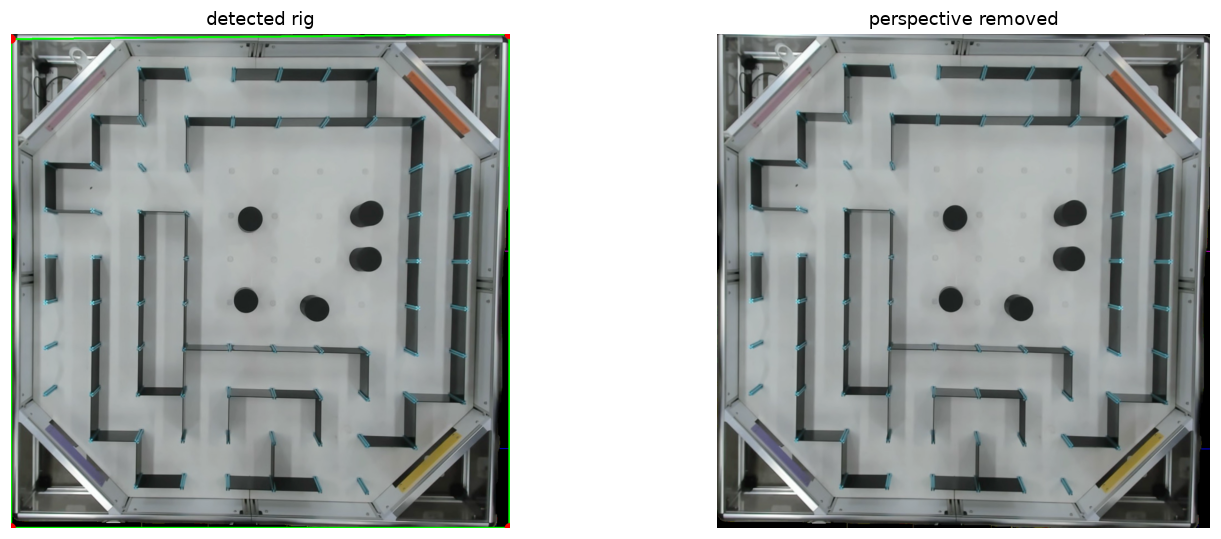

In [4]:
photo = cv2.imread(PHOTO)
if photo is None:
    raise FileNotFoundError(f"could not read {PHOTO!r} - run this notebook from src/task4_code/")

rig_quad = find_rig_quad(photo)
M_coarse = square_transform(rig_quad, COARSE_PX)
coarse   = cv2.warpPerspective(photo, M_coarse, (COARSE_PX, COARSE_PX))

print("rig corners (tl, tr, br, bl):")
for name, (x, y) in zip("tl tr br bl".split(), rig_quad):
    print(f"  {name}  ({x:7.1f}, {y:7.1f})")

marked = photo.copy()
cv2.polylines(marked, [rig_quad.astype(int)], True, (0, 255, 0), 4)
for x, y in rig_quad.astype(int):
    cv2.circle(marked, (x, y), 12, (0, 0, 255), -1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB)); ax[0].set_title("detected rig")
ax[1].imshow(cv2.cvtColor(coarse, cv2.COLOR_BGR2RGB)); ax[1].set_title("perspective removed")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## Stage 2 — read the grid off the wall clips

Every wall is held by a pair of cyan clips, and those clips sit on cell corners.
Isolating them by hue and clustering their centres in x and y recovers the grid
lines directly from the hardware — which is far more reliable than assuming the
maze fills the board.

This maze is 9 × 9, but rows and columns are counted **independently** and
`ROWS`/`COLS` are carried separately from here on, so the size is measured rather
than asserted and a re-shot or differently-shaped board needs no code change.

In [5]:
def find_clips(bgr):
    """Centroids of the cyan wall clips."""
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    hue, sat, val = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]

    mask = ((hue > CLIP_HUE[0]) & (hue < CLIP_HUE[1]) &
            (sat > CLIP_SAT) & (val > CLIP_VAL)).astype(np.uint8) * 255
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))

    n, _, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    return np.array([centroids[i] for i in range(1, n)
                     if stats[i, cv2.CC_STAT_AREA] >= CLIP_AREA])


def cluster_1d(values, tol):
    """Collapse 1-D values into groups whose neighbours are within `tol`."""
    ordered = np.sort(np.asarray(values, float))
    groups = [[ordered[0]]]
    for v in ordered[1:]:
        if v - groups[-1][-1] <= tol:
            groups[-1].append(v)
        else:
            groups.append([v])
    return np.array([np.mean(g) for g in groups])


def infer_grid(clips, tol=CLIP_TOL):
    """Grid line positions (xs, ys) implied by the clip centroids."""
    return cluster_1d(clips[:, 0], tol), cluster_1d(clips[:, 1], tol)

55 clips  ->  9 rows x 9 cols
x lines: [ 68.  150.5 233.6 315.6 398.9 481.9 564.6 644.6 731.3 814.6]
y lines: [ 66.4 152.6 237.4 322.5 406.8 490.5 576.  656.1 735.5 819.8]
cell pitch: 82.9 px (x), 83.7 px (y)


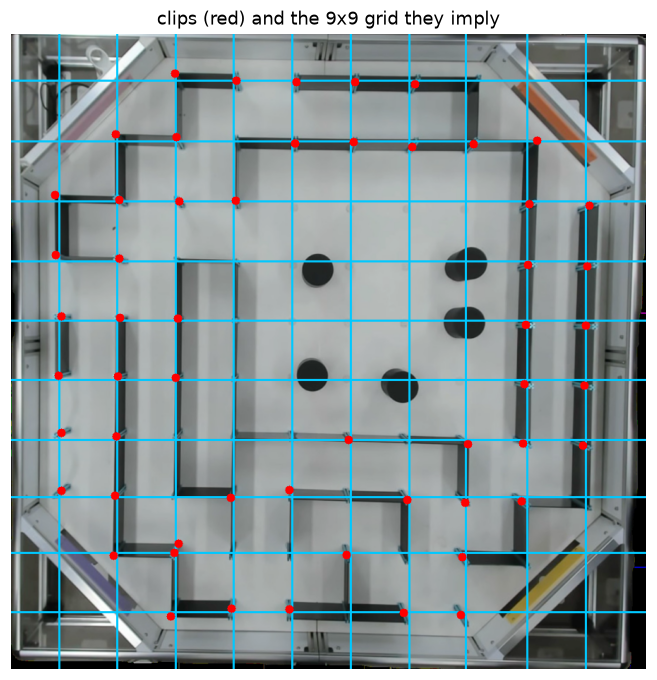

In [6]:
clips  = find_clips(coarse)
gx, gy = infer_grid(clips)

# Counted independently rather than assumed equal, so the size comes from the
# photo. For this board both come out as 9.
COLS, ROWS = len(gx) - 1, len(gy) - 1
if ROWS < 2 or COLS < 2:
    raise RuntimeError(f"implausible {ROWS} x {COLS} grid from {len(clips)} clips "
                       "- widen CLIP_TOL or the hue window")

print(f"{len(clips)} clips  ->  {ROWS} rows x {COLS} cols")
print("x lines:", np.round(gx, 1))
print("y lines:", np.round(gy, 1))
print("cell pitch: %.1f px (x), %.1f px (y)" % (np.diff(gx).mean(), np.diff(gy).mean()))

vis = coarse.copy()
for x in gx: cv2.line(vis, (int(x), 0), (int(x), COARSE_PX), (255, 200, 0), 2)
for y in gy: cv2.line(vis, (0, int(y)), (COARSE_PX, int(y)), (255, 200, 0), 2)
for x, y in clips.astype(int): cv2.circle(vis, (x, y), 6, (0, 0, 255), -1)

plt.figure(figsize=(7.5, 7.5))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"clips (red) and the {ROWS}x{COLS} grid they imply")
plt.axis("off"); plt.show()

## Stage 3 — one homography, photo → maze square

Rather than warping twice and losing sharpness, the rig transform and the
grid-fitting transform are multiplied into a single matrix `M`. The result is a
square where **cell `(r, c)` is exactly the box `[c·CELL_PX, (c+1)·CELL_PX] ×
[r·CELL_PX, (r+1)·CELL_PX]`** — so every later step is plain array slicing.

rectified maze: 900 x 900 px, 100 px per cell


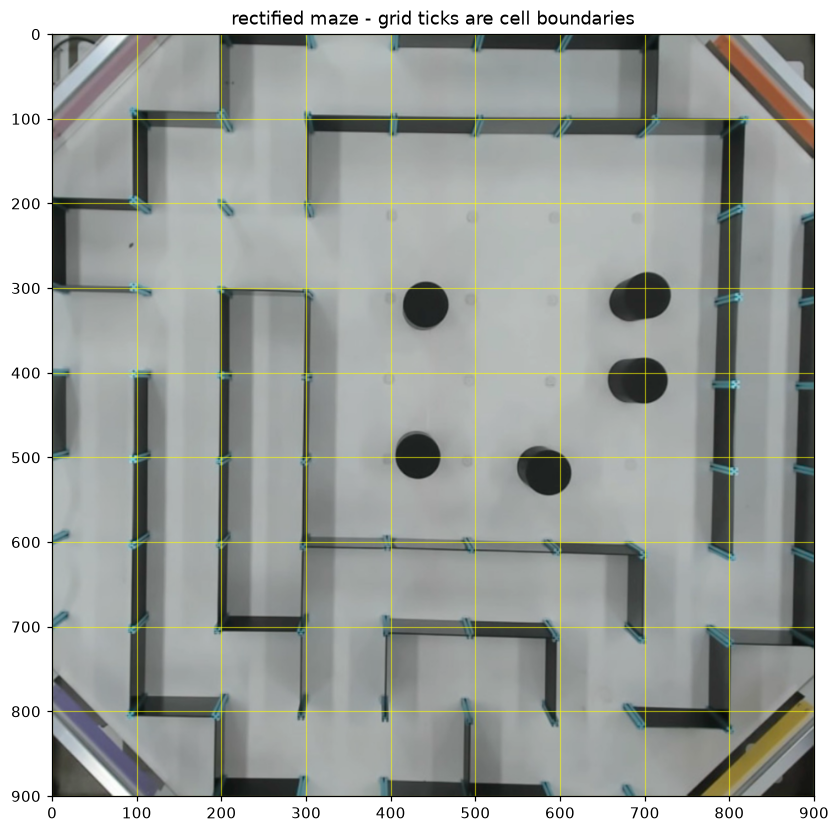

In [7]:
MAZE_W, MAZE_H = COLS * CELL_PX, ROWS * CELL_PX
grid_quad = np.float32([[gx[0],  gy[0]],  [gx[-1], gy[0]],
                        [gx[-1], gy[-1]], [gx[0],  gy[-1]]])

M = cv2.getPerspectiveTransform(
        grid_quad,
        np.float32([[0, 0], [MAZE_W, 0], [MAZE_W, MAZE_H], [0, MAZE_H]])) @ M_coarse
maze_img = cv2.warpPerspective(photo, M, (MAZE_W, MAZE_H))

def cell_centre(r, c):
    return int((c + 0.5) * CELL_PX), int((r + 0.5) * CELL_PX)

print(f"rectified maze: {maze_img.shape[1]} x {maze_img.shape[0]} px, {CELL_PX} px per cell")

plt.figure(figsize=(8 * COLS / max(ROWS, COLS) + 2, 8 * ROWS / max(ROWS, COLS) + 1))
plt.imshow(cv2.cvtColor(maze_img, cv2.COLOR_BGR2RGB))
plt.xticks(np.arange(0, MAZE_W + 1, CELL_PX)); plt.yticks(np.arange(0, MAZE_H + 1, CELL_PX))
plt.grid(color="yellow", alpha=.55)
plt.title("rectified maze - grid ticks are cell boundaries")
plt.show()

## Stage 4 — wall pixels

The board is lit unevenly (bright at the top, shadowed at the bottom), so a fixed
grey threshold cannot separate wall from floor across the whole image. A
morphological *closing* with a kernel wider than any wall estimates the local
floor brightness; dividing by it flattens the lighting and leaves a threshold
that works everywhere.

wall pixels: 21.7% of the board


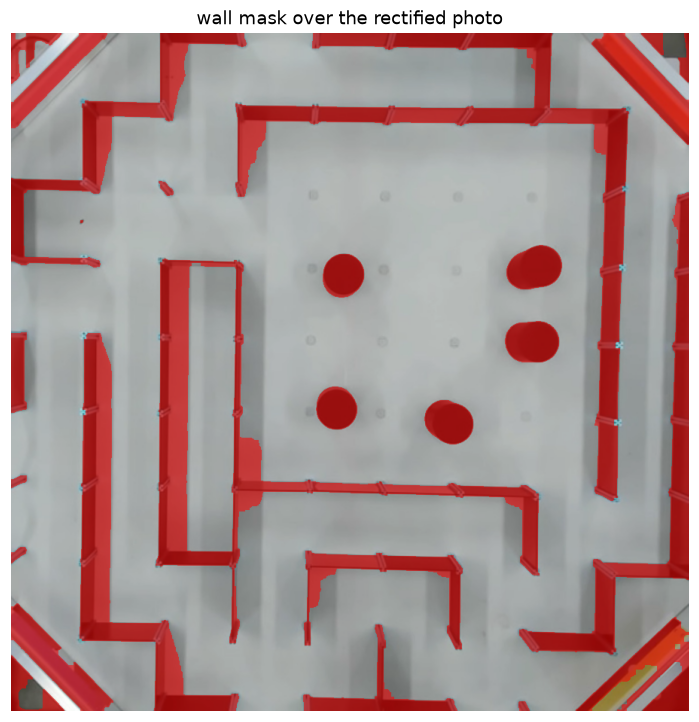

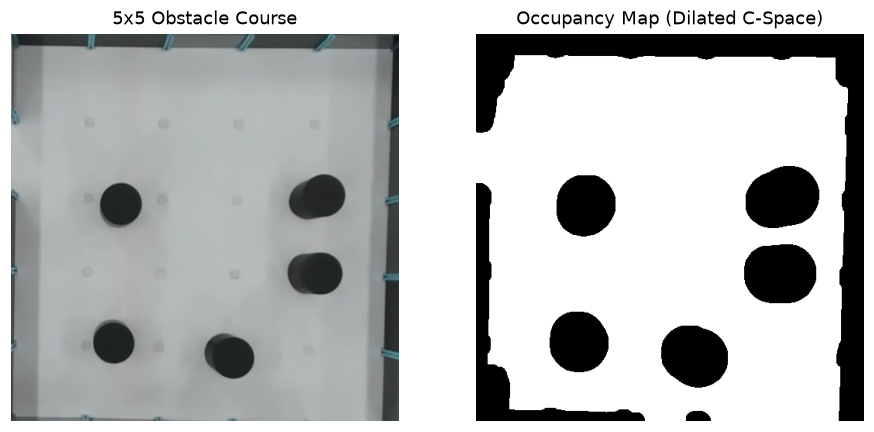

In [8]:
def wall_pixels(bgr):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    # closing with a kernel wider than a wall keeps only the floor -> local brightness
    floor = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, np.ones((61, 61), np.uint8))
    flat  = cv2.divide(gray, floor, scale=255)

    mask = (flat < WALL_LEVEL).astype(np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  np.ones((3, 3), np.uint8))   # speckle
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))   # seams
    return mask

wall_mask = wall_pixels(maze_img)

def extract_and_build_occupancy(mask, start_r, start_c, size_cells):
    # Extract the 5x5 ROI
    y0, x0 = start_r * CELL_PX, start_c * CELL_PX
    y1, x1 = (start_r + size_cells) * CELL_PX, (start_c + size_cells) * CELL_PX
    roi_mask = mask[y0:y1, x0:x1]
    roi_bgr = maze_img[y0:y1, x0:x1].copy()

    # Calculate radius in pixels based on physical specs
    total_radius_mm = 20
    radius_px = int((total_radius_mm / CELL_SIZE_MM) * CELL_PX)

    # Dilate obstacles (Configuration Space mapping)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (radius_px * 2, radius_px * 2))
    c_space = cv2.dilate(roi_mask, kernel)

    # Free space is True (255), obstacles are False (0)
    free_space = cv2.bitwise_not(c_space)
    return free_space, roi_bgr


wall_mask = wall_pixels(maze_img)
print(f"wall pixels: {wall_mask.mean():.1%} of the board")

tint = maze_img.copy(); tint[wall_mask > 0] = (0, 0, 255)
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(cv2.addWeighted(maze_img, .45, tint, .55, 0), cv2.COLOR_BGR2RGB))
plt.title("wall mask over the rectified photo"); plt.axis("off"); plt.show()

free_space_mask, roi_img = extract_and_build_occupancy(wall_mask, ZONE_START_R, ZONE_START_C, ZONE_SIZE)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(roi_img, cv2.COLOR_BGR2RGB)); ax[0].set_title("5x5 Obstacle Course")
ax[1].imshow(free_space_mask, cmap='gray'); ax[1].set_title("Occupancy Map (Dilated C-Space)")
for a in ax: a.axis("off")
plt.show()

## Stage 5 — from pixels to a wall map

This is the step the old ray-casting approach got wrong. Sampling a straight line
between two cell centres asks *"is anything dark in the way"*, which fires on the
side face of a neighbouring wall and misses walls the line clips at an angle.

Instead each **cell edge** is scored on its own. For the edge between two cells we
take a band `±EDGE_HALF` px around it, collapse it along the short axis (so a wall
counts wherever it falls inside the band — this absorbs the parallax lean of a
5 cm wall seen from a camera that is not directly above it), and ask what
fraction of the edge's length is covered.

The ends are trimmed by `EDGE_TRIM`, because the clips and any perpendicular wall
meeting at that corner would otherwise vote for a wall that is not there.

In [9]:
def edge_score(mask, kind, r, c):
    """Covered fraction of one cell edge.

    kind 'H' -> the horizontal edge on the NORTH side of cell (r, c)
    kind 'V' -> the vertical   edge on the WEST  side of cell (r, c)
    """
    trim = int(CELL_PX * EDGE_TRIM)

    if kind == "H":
        y, x0, x1 = r * CELL_PX, c * CELL_PX, (c + 1) * CELL_PX
        band  = mask[max(0, y - EDGE_HALF):y + EDGE_HALF + 1, x0 + trim:x1 - trim]
        along = band.max(axis=0)          # per column: any wall pixel in the band?
    else:
        x, y0, y1 = c * CELL_PX, r * CELL_PX, (r + 1) * CELL_PX
        band  = mask[y0 + trim:y1 - trim, max(0, x - EDGE_HALF):x + EDGE_HALF + 1]
        along = band.max(axis=1)

    return float(along.mean()) if along.size else 0.0


def build_walls(mask, rows, cols):
    """Score every edge, then threshold into two boolean wall maps.

    H[r, c] - wall on the north side of (r, c);  shape (rows+1, cols)
    V[r, c] - wall on the west  side of (r, c);  shape (rows, cols+1)
    """
    h_score = np.array([[edge_score(mask, "H", r, c) for c in range(cols)] for r in range(rows + 1)])
    v_score = np.array([[edge_score(mask, "V", r, c) for c in range(cols + 1)] for r in range(rows)])

    H, V = h_score >= WALL_THR, v_score >= WALL_THR

    # the board edge is a physical barrier even where no wall is clipped to it
    H[0, :] = H[-1, :] = True
    V[:, 0] = V[:, -1] = True
    return H, V, h_score, v_score


H, V, h_score, v_score = build_walls(wall_mask, ROWS, COLS)
print(f"walls found: {H.sum()} horizontal, {V.sum()} vertical "
      f"(of {H.size} and {V.size} possible edges)")

walls found: 44 horizontal, 50 vertical (of 90 and 90 possible edges)


## Stage 6 — the maze as a graph

`Maze` owns the wall maps and answers connectivity questions; `Graph` is the
explicit adjacency structure built from it. Node ids follow the existing
convention, `id = row · COLS + col`, so they read left-to-right then top-to-bottom.

Headings are ordered clockwise, which is what makes the turn from any heading to
any other a single modulo-4 subtraction — so **every** starting orientation is
handled, a 180° reversal included.

In [10]:
HEADINGS = ["N", "E", "S", "W"]                                  # clockwise
DELTA    = {"N": (-1, 0), "E": (0, 1), "S": (1, 0), "W": (0, -1)}


class Node:
    def __init__(self, node_id, x, y):
        self.id, self.x, self.y = node_id, x, y

    def get_point(self):
        return self.x, self.y

    def __repr__(self):
        return f"Node({self.id} @ {self.x},{self.y})"


class Graph:
    def __init__(self):
        self.nodes, self.edges = {}, {}

    def add_node(self, node_id, x, y):
        self.nodes[node_id] = Node(node_id, x, y)
        self.edges.setdefault(node_id, [])

    def add_edge(self, a, b, weight=1):
        self.edges[a].append((b, weight))

    def remove_edge(self, a, b):
        # the original broke out of the loop after one iteration regardless
        self.edges[a] = [e for e in self.edges[a] if e[0] != b]

    def neighbours(self, node_id):
        return [n for n, _ in self.edges[node_id]]

    def get_edge_weight(self, a, b):
        return next((w for n, w in self.edges[a] if n == b), None)

    def __repr__(self):
        return f"Graph({len(self.nodes)} nodes, {sum(map(len, self.edges.values()))} directed edges)"


class Maze:
    """Wall maps plus the search routines that run on them."""

    def __init__(self, H, V):
        self.H, self.V = H, V
        self.rows, self.cols = H.shape[0] - 1, H.shape[1]

    @property
    def shape(self):
        return self.rows, self.cols

    def inside(self, r, c):
        return 0 <= r < self.rows and 0 <= c < self.cols

    # ---------------------------------------------------------- topology
    def wall(self, r, c, d):
        return bool({"N": self.H[r, c],     "S": self.H[r + 1, c],
                     "W": self.V[r, c],     "E": self.V[r, c + 1]}[d])

    def neighbours(self, r, c):
        for d, (dr, dc) in DELTA.items():
            nr, nc = r + dr, c + dc
            if self.inside(nr, nc) and not self.wall(r, c, d):
                yield (nr, nc), d

    def cells(self):
        for r in range(self.rows):
            for c in range(self.cols):
                yield r, c

    # id = row * cols + col, so ids read left-to-right then top-to-bottom
    def node_id(self, r, c):
        return r * self.cols + c

    def cell(self, node_id):
        return divmod(node_id, self.cols)

    def to_graph(self):
        g = Graph()
        for r, c in self.cells():
            x, y = cell_centre(r, c)
            g.add_node(self.node_id(r, c), x, y)
        for r, c in self.cells():
            for (nr, nc), _ in self.neighbours(r, c):
                g.add_edge(self.node_id(r, c), self.node_id(nr, nc), 1)
        return g

    # ---------------------------------------------------------- search
    def bfs(self, start, goal):
        """Fewest-cells path from start to goal, or None."""
        if start == goal:
            return [start]

        came_from = {start: None}
        queue = deque([start])
        while queue:
            current = queue.popleft()
            for nb, _ in self.neighbours(*current):
                if nb in came_from:
                    continue
                came_from[nb] = current
                if nb == goal:
                    path = [nb]
                    while came_from[path[-1]] is not None:
                        path.append(came_from[path[-1]])
                    return path[::-1]
                queue.append(nb)
        return None

    def flood(self, goal):
        """Classic micromouse flood fill: cell -> moves to reach `goal` (-1 = unreachable)."""
        dist = np.full((self.rows, self.cols), -1, int)
        dist[goal] = 0
        queue = deque([goal])
        while queue:
            current = queue.popleft()
            for nb, _ in self.neighbours(*current):
                if dist[nb] < 0:
                    dist[nb] = dist[current] + 1
                    queue.append(nb)
        return dist

    def components(self):
        seen, groups = set(), []
        for start in self.cells():
            if start in seen:
                continue
            queue, group = deque([start]), []
            seen.add(start)
            while queue:
                current = queue.popleft()
                group.append(current)
                for nb, _ in self.neighbours(*current):
                    if nb not in seen:
                        seen.add(nb)
                        queue.append(nb)
            groups.append(group)
        return sorted(groups, key=len, reverse=True)

    # ---------------------------------------------------------- rendering
    def ascii(self, path=(), start=None, goal=None):
        marks = {cell: PATH_DOT for cell in path}
        if start is not None: marks[start] = "S"
        if goal  is not None: marks[goal]  = "G"

        lines = []
        for r in range(self.rows + 1):
            lines.append("".join("+" + ("---" if self.H[r, c] else "   ")
                                 for c in range(self.cols)) + "+")
            if r < self.rows:
                lines.append("".join(("|" if self.V[r, c] else " ") + f" {marks.get((r, c), ' ')} "
                                     for c in range(self.cols))
                             + ("|" if self.V[r, self.cols] else " "))
        return "\n".join(lines)

def astar_pixel_grid(free_space, start, goal):
    h, w = free_space.shape
    open_set = []
    heapq.heappush(open_set, (0, start))
    came_from = {}

    g_score = {start: 0}

    # 8-connected grid (diagonals cost 1.414)
    neighbors = [(0,1, 1), (1,0, 1), (0,-1, 1), (-1,0, 1), 
                 (1,1, 1.414), (1,-1, 1.414), (-1,1, 1.414), (-1,-1, 1.414)]

    while open_set:
        _, current = heapq.heappop(open_set)

        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        for dx, dy, cost in neighbors:
            nx, ny = current[0] + dx, current[1] + dy

            # Check bounds and collisions
            if 0 <= nx < w and 0 <= ny < h:
                if free_space[ny, nx] == 0:
                    continue

                tentative_g = g_score[current] + cost
                neighbor = (nx, ny)

                if tentative_g < g_score.get(neighbor, float('inf')):
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score = tentative_g + math.hypot(goal[0]-nx, goal[1]-ny) # Euclidean heuristic
                    heapq.heappush(open_set, (f_score, neighbor))
    return None

def smooth_path(pixel_path, epsilon_px=10.0):
    pts = np.array(pixel_path, dtype=np.int32).reshape((-1, 1, 2))
    waypoints = cv2.approxPolyDP(pts, epsilon=epsilon_px, closed=False)
    return [tuple(pt[0]) for pt in waypoints]

print("Solving continuous pixel grid... (this may take a few seconds)")
dense_path = astar_pixel_grid(free_space_mask, ZONE_START_PX, ZONE_GOAL_PX)

if dense_path is None:
    raise RuntimeError("No valid continuous path found in the obstacle course.")

waypoints = smooth_path(dense_path)
print(f"Path found! Reduced from {len(dense_path)} pixels to {len(waypoints)} waypoints.")

Solving continuous pixel grid... (this may take a few seconds)
Path found! Reduced from 401 pixels to 4 waypoints.


In [11]:
maze  = Maze(H, V)
graph = maze.to_graph()
print(graph)

Graph(81 nodes, 172 directed edges)


## Display 5x5 path

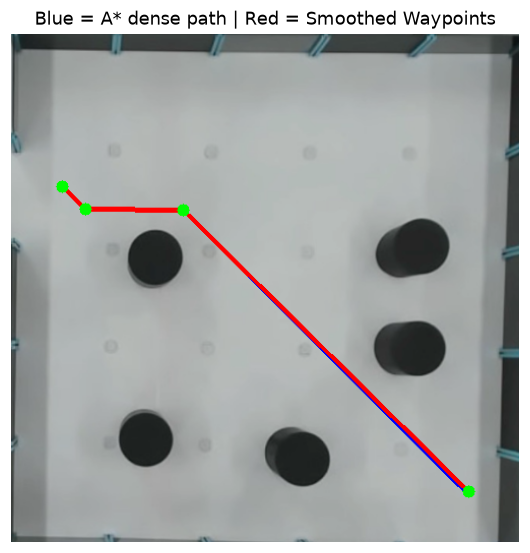

In [12]:
# Visually verify
vis_img = roi_img.copy()
# Draw dense path
for i in range(len(dense_path)-1):
    cv2.line(vis_img, dense_path[i], dense_path[i+1], (255, 0, 0), 2)
# Draw waypoints
for i in range(len(waypoints)-1):
    cv2.line(vis_img, waypoints[i], waypoints[i+1], (0, 0, 255), 4)
    cv2.circle(vis_img, waypoints[i], 6, (0, 255, 0), -1)
cv2.circle(vis_img, waypoints[-1], 6, (0, 255, 0), -1)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
plt.title("Blue = A* dense path | Red = Smoothed Waypoints")
plt.axis("off")
plt.show()

## Stage 7 — commands for the robot

Get commands from both 4.1, and the specific turns and movement for 4.2.

In [49]:
TURN = {0: [], 1: ["r"], 2: ["r", "r"], 3: ["l"]}     # clockwise quarter-turns -> commands


def turn_to(heading, facing):
    """Commands that rotate from `heading` to `facing` (180 deg becomes 'rr')."""
    return TURN[(HEADINGS.index(facing) - HEADINGS.index(heading)) % 4]


def path_to_commands(path, heading, final_heading=None):
    """Cell path + starting heading -> (commands, final heading).

    Any of N/E/S/W works as the starting heading; the first move simply gets
    however many turns it needs, including a 'rr' reversal.

    `final_heading` is optional - the brief gives the goal as (row, col) with no
    direction, so by default the robot stops facing whichever way it arrived.
    Pass one to append the turns that park it facing that way.
    """
    commands = []
    for (r0, c0), (r1, c1) in zip(path, path[1:]):
        facing = {(-1, 0): "N", (0, 1): "E", (1, 0): "S", (0, -1): "W"}[(r1 - r0, c1 - c0)]
        commands += turn_to(heading, facing)
        commands.append("f")
        heading = facing

    if final_heading is not None:
        commands += turn_to(heading, final_heading)
        heading = final_heading
    return commands, heading


def replay(maze, start, commands, heading):
    """Independent check: walk the command string, refusing to pass through a wall.

    Returns the (cell, heading) the robot ends up in.
    """
    r, c = start
    for cmd in commands:
        if cmd == "f":
            assert not maze.wall(r, c, heading), f"command drives into a wall at ({r},{c})"
            dr, dc = DELTA[heading]
            r, c = r + dr, c + dc
        else:
            step = 1 if cmd == "r" else -1
            heading = HEADINGS[(HEADINGS.index(heading) + step) % 4]
    return (r, c), heading

def generate_relative_commands(waypoints, initial_heading_deg):
    commands = []
    current_heading = initial_heading_deg

    for i in range(len(waypoints) - 1):
        x1, y1 = waypoints[i]
        x2, y2 = waypoints[i+1]

        dist_px = math.hypot(x2 - x1, y2 - y1)
        dist_mm = dist_px * (CELL_SIZE_MM / CELL_PX)

        # Calculate angle of line segment
        # Invert y difference because image Y-axis goes down
        angle_rad = math.atan2(-(y2 - y1), x2 - x1)
        angle_deg = math.degrees(angle_rad)

        turn_deg = angle_deg - current_heading
        turn_deg = (turn_deg + 180) % 360 - 180  # Normalize to [-180, 180]

        commands.append({
            "turn_deg": round(turn_deg, 1),
            "drive_mm": round(dist_mm, 1)
        })
        current_heading = angle_deg

    return commands

firmware_commands = generate_relative_commands(waypoints, 0)

def generate_discrete_commands(path_nodes, start_heading_deg):
    """
    Converts a list of (row, col) tuples into a string of discrete commands.
    Returns: (command_string, final_heading_deg)
    """
    cmds = ""
    current_heading = start_heading_deg

    for i in range(1, len(path_nodes)):
        r1, c1 = path_nodes[i - 1]
        r2, c2 = path_nodes[i]

        # Determine required absolute heading to reach the next cell
        if r2 < r1:   req_heading = -90.0  # North
        elif r2 > r1: req_heading = 90.0   # South
        elif c2 > c1: req_heading = 0.0    # East
        elif c2 < c1: req_heading = 180.0  # West
        else: continue

        # Calculate relative turn required
        turn = req_heading - current_heading
        turn = (turn + 180) % 360 - 180

        # Append turn commands
        if turn == 90.0:   cmds += "r"
        elif turn == -90.0:  cmds += "l"
        elif turn == 180.0 or turn == -180.0: cmds += "ll" # U-turn

        # Append forward command
        cmds += "f"
        current_heading = req_heading

    return cmds, current_heading



firmware_commands = generate_relative_commands(waypoints, -90)

In [50]:
# puts all the commands in one array
def build_master_mission(start_node, zone_enter, zone_exit, goal_node, initial_heading, waypoints, maze_obj):
    unified_commands = []

    # ---------------------------------------------------------
    # PHASE 1: Path A (Start -> Zone Entrance)
    # ---------------------------------------------------------
    path_a_nodes = maze_obj.bfs(start_node, zone_enter)

    if path_a_nodes is None:
        raise ValueError(f"PATH BLOCKED: No route found from Start {start_node} to Zone Enter {zone_enter}. Check your coordinates!")

    path_a_str, heading_at_entrance = generate_discrete_commands(path_a_nodes, initial_heading)

    for char in path_a_str:
        unified_commands.append(f"{{'{char}', 0.0}}")

    # ---------------------------------------------------------
    # PHASE 2: Continuous Obstacle Zone
    # ---------------------------------------------------------
    # FIX 2: Dynamically calculate the relative waypoint commands using
    # the exact heading the robot has when it finishes Phase 1.
    zone_commands = generate_relative_commands(waypoints, heading_at_entrance)

    final_continuous_heading = heading_at_entrance

    for cmd in zone_commands:
        if abs(cmd["turn_deg"]) > 1.0:
            unified_commands.append(f"{{'T', {cmd['turn_deg']}}}")
            final_continuous_heading += cmd["turn_deg"]

        if cmd["drive_mm"] > 1.0:
            unified_commands.append(f"{{'D', {cmd['drive_mm']}}}")

    # Normalize final continuous heading to [-180, 180]
    final_continuous_heading = (final_continuous_heading + 180) % 360 - 180

    # ---------------------------------------------------------
    # PHASE 3: The Snap ('S')
    # ---------------------------------------------------------
    unified_commands.append("{'S', 0.0}")

    # Round to the nearest 90 degrees to simulate the Arduino snap
    snapped_heading = round(final_continuous_heading / 90.0) * 90.0
    snapped_heading = (snapped_heading + 180) % 360 - 180

    # ---------------------------------------------------------
    # PHASE 4: Path B (Zone Exit -> Final Goal)
    # ---------------------------------------------------------
    path_b_nodes = maze_obj.bfs(zone_exit, goal_node)

    # FIX 3: Safety check for the final exit path
    if path_b_nodes is None:
        raise ValueError(f"PATH BLOCKED: No route found from Zone Exit {zone_exit} to Goal {goal_node}. Check your coordinates!")

    path_b_str, final_heading = generate_discrete_commands(path_b_nodes, snapped_heading)

    for char in path_b_str:
        unified_commands.append(f"{{'{char}', 0.0}}")

    return unified_commands

Full Route Plot

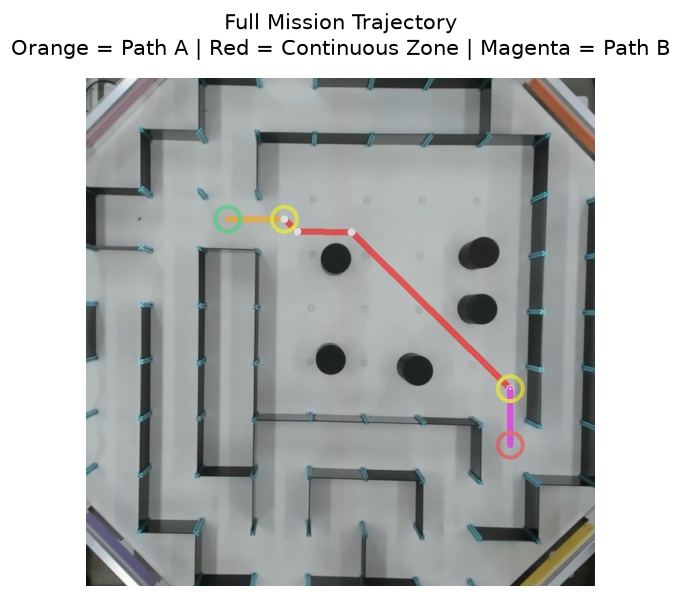

In [51]:
def plot_master_mission(maze_img, start_node, zone_enter, zone_exit, goal_node, waypoints, zone_start_r, zone_start_c):
    # Get the base image and convert to RGB for Matplotlib
    rgb = cv2.cvtColor(maze_img, cv2.COLOR_BGR2RGB)
    overlay = rgb.copy()

    # ---------------------------------------------------------
    # 1. Get Coordinates for Path A (Discrete)
    # ---------------------------------------------------------
    path_a_nodes = maze.bfs(start_node, zone_enter)
    pts_a = [cell_centre(r, c) for r, c in path_a_nodes]

    # ---------------------------------------------------------
    # 2. Get Global Coordinates for Continuous Waypoints
    # ---------------------------------------------------------
    # Calculate the pixel offset of the 5x5 ROI's top-left corner
    offset_x = zone_start_c * CELL_PX
    offset_y = zone_start_r * CELL_PX

    # Shift local waypoint coordinates back into global image coordinates
    pts_w = [(x + offset_x, y + offset_y) for x, y in waypoints]

    # ---------------------------------------------------------
    # 3. Get Coordinates for Path B (Discrete)
    # ---------------------------------------------------------
    path_b_nodes = maze.bfs(zone_exit, goal_node)
    pts_b = [cell_centre(r, c) for r, c in path_b_nodes]

    # ---------------------------------------------------------
    # 4. Draw the Paths
    # ---------------------------------------------------------
    # Draw Path A (Orange)
    for p, q in zip(pts_a, pts_a[1:]):
        cv2.line(overlay, p, q, (255, 165, 0), 10)

    # Draw Continuous Waypoints (Red)
    for p, q in zip(pts_w, pts_w[1:]):
        cv2.line(overlay, p, q, (255, 0, 0), 10)
        cv2.circle(overlay, p, 7, (255, 255, 255), -1) # White dots at waypoint nodes
    cv2.circle(overlay, pts_w[-1], 7, (255, 255, 255), -1)

    # Draw Path B (Magenta)
    for p, q in zip(pts_b, pts_b[1:]):
        cv2.line(overlay, p, q, (255, 0, 255), 10)

    # ---------------------------------------------------------
    # 5. Connect the Transition Points (White thin lines)
    # ---------------------------------------------------------
    cv2.line(overlay, pts_a[-1], pts_w[0], (255, 255, 255), 4)
    cv2.line(overlay, pts_w[-1], pts_b[0], (255, 255, 255), 4)

    # ---------------------------------------------------------
    # 6. Mark the Key Nodes
    # ---------------------------------------------------------
    cv2.circle(overlay, pts_a[0], 22, (46, 220, 110), 6)  # Start (Green Outline)
    cv2.circle(overlay, pts_a[-1], 22, (255, 255, 0), 6)  # Zone Enter (Yellow Outline)
    cv2.circle(overlay, pts_b[0], 22, (255, 255, 0), 6)   # Zone Exit (Yellow Outline)
    cv2.circle(overlay, pts_b[-1], 22, (255, 64, 64), 6)  # Goal (Red Outline)

    # Blend the overlay with the original image so we can still see the maze texture
    out = cv2.addWeighted(rgb, 0.45, overlay, 0.55, 0)

    # ---------------------------------------------------------
    # 7. Render Plot
    # ---------------------------------------------------------
    plt.figure(figsize=(6, 6))
    plt.imshow(out)
    plt.title("Full Mission Trajectory\nOrange = Path A | Red = Continuous Zone | Magenta = Path B", fontsize=14, pad=15)
    plt.axis("off")
    plt.show()

# Execute the visualization using your global variables
plot_master_mission(
    maze_img=maze_img,
    start_node=START,
    zone_enter=ZONE_ENTER,
    zone_exit=ZONE_EXIT,
    goal_node=GOAL,
    waypoints=waypoints,
    zone_start_r=ZONE_START_R,
    zone_start_c=ZONE_START_C
)

## Stage 10 — hand it to the firmware

Writes `maze_route.h` next to the notebook: drop it in `src/task4_code/` and call
`chainMovement(mouse, MAZE_ROUTE)`.

In [52]:
# 5x5 specific print for debugging
print("\n--- CONTINUOUS COMMANDS EXPORT ---")
print("Command Sequence (Relative turn, then drive straight):")
for i, cmd in enumerate(firmware_commands):
    print(f"Step {i+1}: Turn {cmd['turn_deg']:>6.1f}° | Drive {cmd['drive_mm']:>5.1f} mm")

# C-Header string formatting
c_array = ", ".join([f"{{{c['turn_deg']}, {c['drive_mm']}}}" for c in firmware_commands])

c_header = f"""#pragma once
// Generated by task4_code/image_processing.ipynb for Task 4.2
// Start position in 5x5 zone: {ZONE_START_PX}
// Goal position in 5x5 zone: {ZONE_GOAL_PX}

struct WaypointCmd {{
    float turn_deg;
    float drive_mm;
}};

constexpr int NUM_WAYPOINTS = {len(firmware_commands)};
constexpr WaypointCmd OBSTACLE_ROUTE[NUM_WAYPOINTS] = {{
    {c_array}
}};
"""

with open("5x5_route.h", "w") as f:
    f.write(c_header)
    
print("\nExported to '5x5_route.h'!")


--- CONTINUOUS COMMANDS EXPORT ---
Command Sequence (Relative turn, then drive straight):
Step 1: Turn   46.3° | Drive  57.3 mm
Step 2: Turn   43.1° | Drive 172.8 mm
Step 3: Turn  -44.0° | Drive 710.2 mm

Exported to '5x5_route.h'!


In [53]:
# Generate the string array (Passing waypoints and maze into the function)
master_mission = build_master_mission(
    START,
    ZONE_ENTER,
    ZONE_EXIT,
    GOAL,
    START_HEADING,
    waypoints,
    maze
)

c_array = ",\n    ".join(master_mission)

# Write to file
c_header = f"""#pragma once
// Master Mission Profile
// Contains discrete grid commands and continuous waypoints.

struct Command {{
    char action;
    float value;
}};

constexpr int NUM_COMMANDS = {len(master_mission)};
constexpr Command MISSION[NUM_COMMANDS] = {{
    {c_array}
}};
"""

with open("4_2_full_route.h", "w") as f:
    f.write(c_header)

print("Mission Profile successfully exported to '4_2_full_route.h'!")

Mission Profile successfully exported to '4_2_full_route.h'!
